# Healthcare Capstone — EDA: Patient Encounters
**Name:** Francisco Molina  
**Role:** Dev Engineer / ML Lead (Models 1 & 2)  
**Team:** ClearSight Analytics  
**Date:** March 25, 2026

---

## Objective

Explore the patient_encounters_2023.csv dataset to understand the data before building readmission prediction models. This notebook documents my findings, data quality issues, and key patterns that will inform our feature engineering and model design.

**Clinical question:** Will this diabetic patient be readmitted to the hospital?

**My models:**
- Model 1: Traditional ML (XGBoost) — must be interpretable (SHAP)
- Model 2: Deep Neural Network (TensorFlow/Keras) — compare vs Model 1

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

# Load the raw data
df = pd.read_csv('data/raw/patient_encounters_2023.csv')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. First Look at the Data

Before doing anything, I want to understand the basic structure: how many rows, what columns exist, what data types we're working with, and if there are any obvious issues at first glance.

In [3]:
# Basic info about the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total encounters: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\n--- Data Types ---")
print(f"Numeric columns: {df.select_dtypes(include='number').shape[1]}")
print(f"Text/categorical columns: {df.select_dtypes(include='object').shape[1]}")
print(f"\n--- Column Names by Type ---")
print(f"\nNumeric: {list(df.select_dtypes(include='number').columns)}")
print(f"\nCategorical: {list(df.select_dtypes(include='object').columns)}")

DATASET OVERVIEW
Total encounters: 101,766
Total columns: 50

--- Data Types ---
Numeric columns: 13
Text/categorical columns: 37

--- Column Names by Type ---

Numeric: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted

### Observations

- We have **101,766 patient encounters** with **50 columns** — this is a substantial dataset
- 13 numeric columns and 37 categorical/text columns
- Many columns that look like they should be numeric (like `weight`, `medical_specialty`) loaded as text — this is suspicious and worth investigating
- I see medication columns (metformin, insulin, etc.) and diagnostic codes (diag_1, diag_2, diag_3) that will need special handling

## 2. The Hidden Trap: Missing Values Encoded as '?'

In most datasets, missing values show up as empty cells (NaN). But healthcare data is different. Let me check if there's something unusual hiding in the text columns.

HUNTING FOR HIDDEN MISSING VALUES


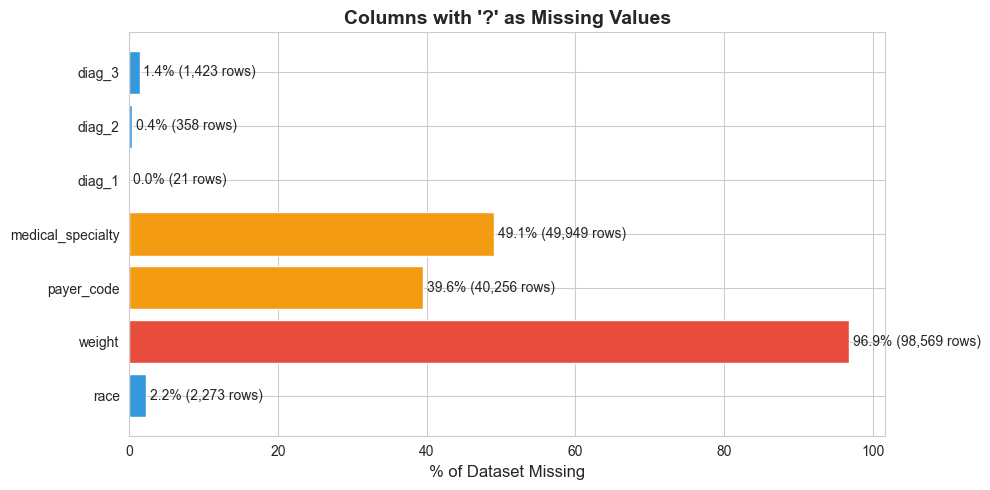

In [4]:
# Let's check for '?' values in every text column
print("=" * 60)
print("HUNTING FOR HIDDEN MISSING VALUES")
print("=" * 60)

question_marks = {}
for col in df.select_dtypes(include='object').columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        question_marks[col] = q_count

# Visualize it
fig, ax = plt.subplots(figsize=(10, 5))
cols = list(question_marks.keys())
vals = list(question_marks.values())
pcts = [v / len(df) * 100 for v in vals]

bars = ax.barh(cols, pcts, color=['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db' for p in pcts])
ax.set_xlabel('% of Dataset Missing', fontsize=12)
ax.set_title("Columns with '?' as Missing Values", fontsize=14, fontweight='bold')

for bar, pct, count in zip(bars, pcts, vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}% ({count:,} rows)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Key Finding: Missing Values are '?' NOT Empty Cells

This is a critical data trap. If we don't replace '?' with NaN, pandas won't recognize them as missing and our analysis will be wrong.

| Column | Missing % | Clinical Explanation |
|--------|-----------|---------------------|
| **weight** | 96.9% | Only recorded for specific admission types — practically useless as a feature |
| **medical_specialty** | 49.1% | Often undocumented in ER admissions — the missingness itself tells us something |
| **payer_code** | 39.6% | Insurance info sometimes unavailable |
| **race** | 2.2% | Small amount — can handle with imputation |
| **diag_1, diag_2, diag_3** | <1.4% | A few missing diagnostic codes — minor issue |

**Important insight:** In healthcare, missingness is rarely random. A missing glucose test means the clinician didn't think it was necessary — that's clinical information we can use as a feature.

In [5]:
# Fix: Replace all '?' with NaN
df.replace('?', np.nan, inplace=True)

# Verify the fix worked
print("After replacing '?' with NaN:")
print(f"Total null values in dataset: {df.isnull().sum().sum():,}")
print(f"\nTop 10 columns by missing %:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(missing_pct.sort_values(ascending=False).head(10))

After replacing '?' with NaN:
Total null values in dataset: 374,017

Top 10 columns by missing %:
weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
encounter_id          0.0
troglitazone          0.0
dtype: float64


## 3. Target Variable: Readmission

This is the most important column in the dataset. The client wants us to predict: **will this patient be readmitted to the hospital?**

According to the client meeting document and preprocessing_hints.py, the raw `readmitted` column has 3 values that we need to convert to binary.

TARGET VARIABLE: readmitted

Raw value counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


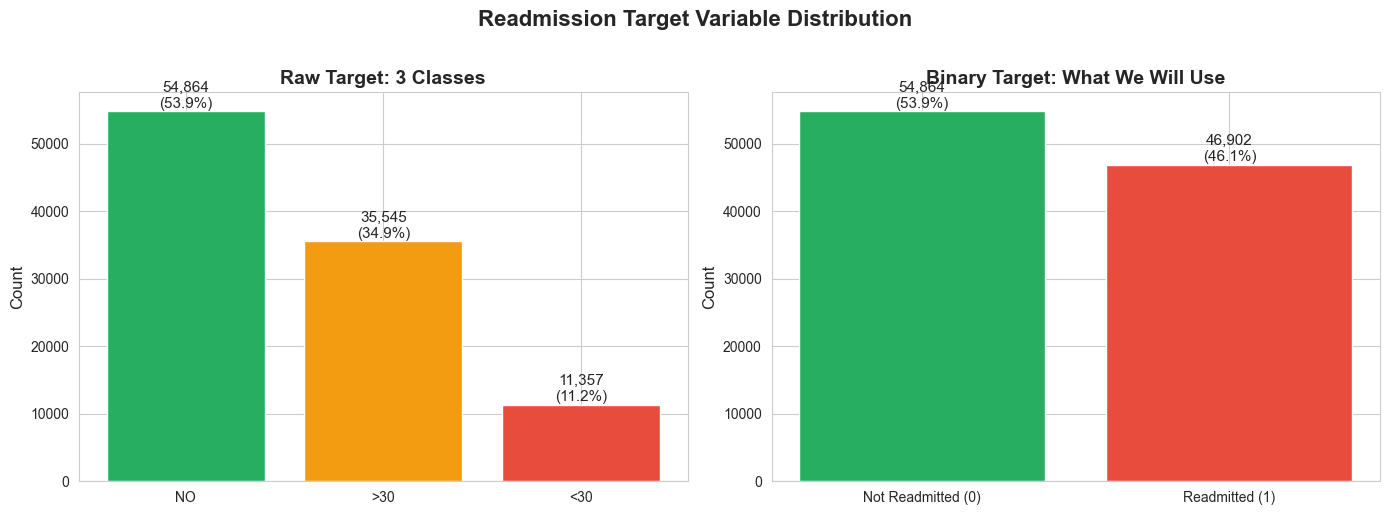

In [6]:
# Explore the target variable
print("=" * 60)
print("TARGET VARIABLE: readmitted")
print("=" * 60)
print(f"\nRaw value counts:")
print(df['readmitted'].value_counts())

# Visualize raw distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw 3-class distribution
colors_raw = ['#27ae60', '#f39c12', '#e74c3c']
raw_counts = df['readmitted'].value_counts()
bars = axes[0].bar(raw_counts.index, raw_counts.values, color=colors_raw, edgecolor='white')
axes[0].set_title('Raw Target: 3 Classes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for bar, count in zip(bars, raw_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Right: Binary conversion
binary_counts = {
    'Not Readmitted (0)': raw_counts.get('NO', 0),
    'Readmitted (1)': raw_counts.get('>30', 0) + raw_counts.get('<30', 0)
}
colors_bin = ['#27ae60', '#e74c3c']
bars2 = axes[1].bar(binary_counts.keys(), binary_counts.values(), color=colors_bin, edgecolor='white')
axes[1].set_title('Binary Target: What We Will Use', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
for bar, count in zip(bars2, binary_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)

plt.suptitle('Readmission Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations on the Target

- The raw column has 3 values: **NO** (53.9%), **>30 days** (34.9%), **<30 days** (11.2%)
- Per the preprocessing_hints.py instructions, we convert to **binary**: both `<30` and `>30` become **1** (readmitted), and `NO` becomes **0** (not readmitted)
- After conversion: **46.1% readmitted / 53.9% not readmitted** — this is fairly balanced, which is good news
- There IS some imbalance but it's not extreme. Still, we must use:
  - Stratified train/test splits
  - class_weight='balanced' or SMOTE
  - Weighted F1 and AUC-ROC as metrics (NOT accuracy alone)

**Clinical context:** The client's current model has 68% AUC-ROC and clinicians don't trust it. Our minimum benchmark is AUC-ROC > 0.70, stretch goal is > 0.80.

## 4. Critical Data Cleaning: Excluding Death & Hospice Patients

Before building any model, we must exclude patients who died or were discharged to hospice. These patients **cannot** be readmitted — including them would create data leakage because their outcome is guaranteed to be "not readmitted" for reasons unrelated to care quality.

The clinical_codes_reference.csv file tells us which discharge disposition IDs to exclude.

DISCHARGE DISPOSITION CODES

Discharge dispositions to EXCLUDE:
  ID 11 — Expired: 1,642 patients
  ID 13 — Hospice / home: 399 patients
  ID 14 — Hospice / medical facility: 372 patients
  ID 19 — Expired at home (Medicaid, hospice): 8 patients
  ID 20 — Expired in medical facility (Medicaid, hospice): 2 patients
  ID 21 — Expired, place unknown (Medicaid, hospice): 0 patients

  TOTAL TO EXCLUDE: 2,423 patients (2.4%)


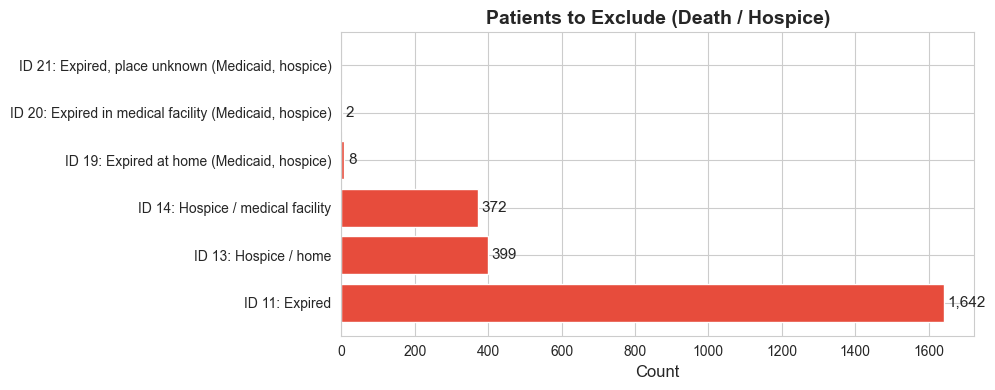


After exclusion: 101,766 → 99,343 rows (2,423 removed)


In [7]:
# Load the clinical codes reference to understand discharge dispositions
codes = pd.read_csv('data/raw/clinical_codes_reference.csv', header=None, skip_blank_lines=False)

# The file has 3 sections. Let's find the discharge dispositions.
# Print rows 10-32 which contain the discharge section
print("=" * 60)
print("DISCHARGE DISPOSITION CODES")
print("=" * 60)

# Extract discharge dispositions manually
discharge_ids = [11, 13, 14, 19, 20, 21]
discharge_labels = {
    11: 'Expired',
    13: 'Hospice / home',
    14: 'Hospice / medical facility',
    19: 'Expired at home (Medicaid, hospice)',
    20: 'Expired in medical facility (Medicaid, hospice)',
    21: 'Expired, place unknown (Medicaid, hospice)'
}

print("\nDischarge dispositions to EXCLUDE:")
for did, label in discharge_labels.items():
    count = (df['discharge_disposition_id'] == did).sum()
    print(f"  ID {did:2d} — {label}: {count:,} patients")

total_exclude = df['discharge_disposition_id'].isin(discharge_ids).sum()
print(f"\n  TOTAL TO EXCLUDE: {total_exclude:,} patients ({total_exclude/len(df)*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
labels = [f"ID {k}: {v}" for k, v in discharge_labels.items()]
counts = [(df['discharge_disposition_id'] == did).sum() for did in discharge_ids]
bars = ax.barh(labels, counts, color='#e74c3c', edgecolor='white')
ax.set_title('Patients to Exclude (Death / Hospice)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

# Apply the exclusion
df_clean = df[~df['discharge_disposition_id'].isin(discharge_ids)].copy()
print(f"\nAfter exclusion: {len(df):,} → {len(df_clean):,} rows ({len(df)-len(df_clean):,} removed)")

### Why This Matters

- **2,423 patients** were removed (2.4% of data) — mostly expired patients (1,642) and hospice discharges (771)
- Without this step, our model would learn that "dead patients don't come back" and count that as a correct prediction — that's **data leakage** (-10 point penalty)
- This is explicitly called out in both the preprocessing_hints.py and the client meeting document
- From this point forward, I'll use `df_clean` for all analysis

## 5. Age Distribution

The client document warned us that age is stored in a "non-numeric format." Let's see what that looks like and how to fix it.

Unique age values:
age
[0-10)        160
[10-20)       690
[20-30)      1649
[30-40)      3764
[40-50)      9607
[50-60)     17060
[60-70)     22059
[70-80)     25331
[80-90)     16434
[90-100)     2589
Name: count, dtype: int64


C:\Users\tecat\AppData\Local\Temp\ipykernel_18592\3722059303.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  readmit_by_age = df_clean.groupby('age_numeric').apply(


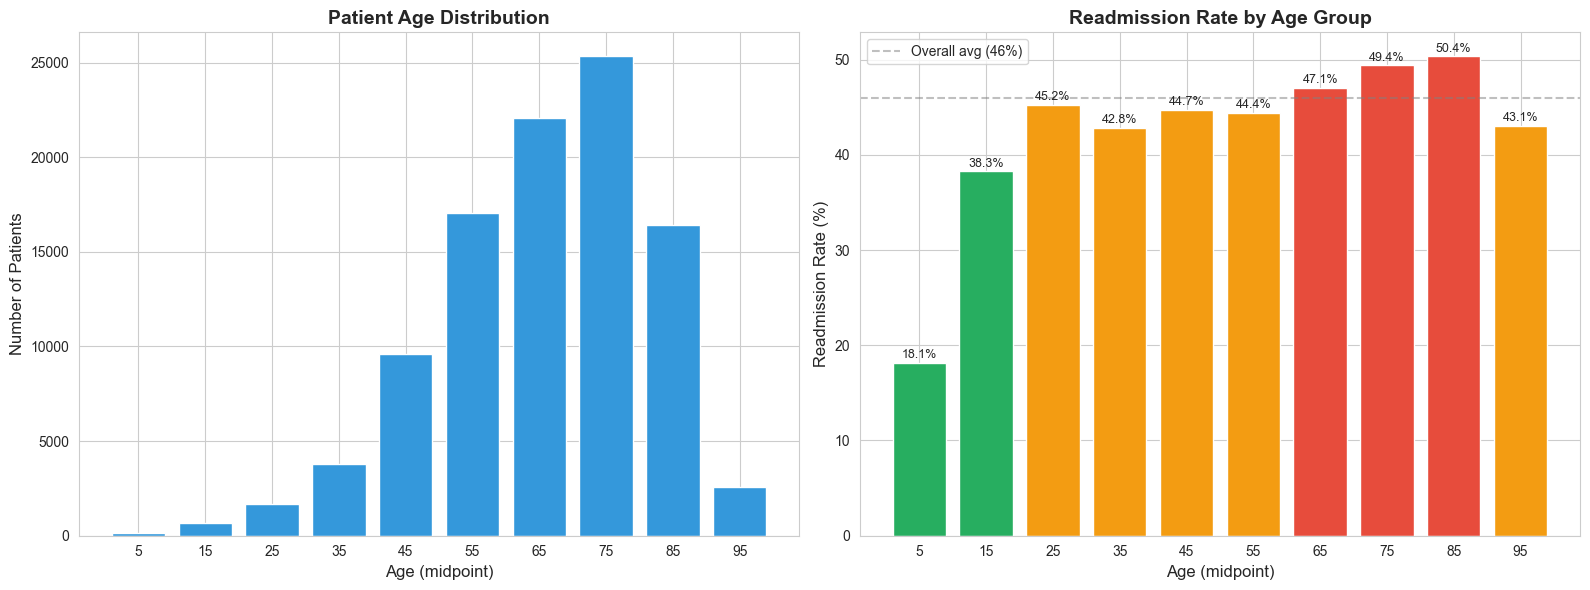

In [8]:
# Explore the age column
print("Unique age values:")
print(df_clean['age'].value_counts().sort_index())

# Convert age brackets to numeric midpoints
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45, '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95,
}
df_clean['age_numeric'] = df_clean['age'].map(age_map)

# Visualize age distribution with readmission rates overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Age distribution
age_counts = df_clean['age_numeric'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, width=8, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Age (midpoint)', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].set_title('Patient Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(age_map.values()))

# Right: Readmission rate by age
readmit_by_age = df_clean.groupby('age_numeric').apply(
    lambda x: (x['readmitted'] != 'NO').mean() * 100
).reset_index()
readmit_by_age.columns = ['age', 'readmission_rate']

bars = axes[1].bar(readmit_by_age['age'], readmit_by_age['readmission_rate'],
                    width=8, color=['#e74c3c' if r > 47 else '#f39c12' if r > 40 else '#27ae60'
                                     for r in readmit_by_age['readmission_rate']],
                    edgecolor='white')
axes[1].set_xlabel('Age (midpoint)', fontsize=12)
axes[1].set_ylabel('Readmission Rate (%)', fontsize=12)
axes[1].set_title('Readmission Rate by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(age_map.values()))
axes[1].axhline(y=46, color='gray', linestyle='--', alpha=0.5, label='Overall avg (46%)')
axes[1].legend()

for bar, rate in zip(bars, readmit_by_age['readmission_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Observations on Age

- Age is stored as text brackets like `[70-80)` — converted to midpoints for modeling (e.g., 75)
- **Most patients are 60-80 years old** — this makes clinical sense for a diabetes-focused hospital system
- Readmission rate **climbs with age**: from 18% at age 0-10 up to ~48% at age 80-90
- Interesting drop at 90+: down to ~40% — likely **survivorship bias** (the sickest patients don't survive to 90, so those who do are actually healthier)
- Very few patients under 30 — these are outliers in a diabetes dataset
- **Conclusion:** Age will be a useful feature, especially for patients 60+

## 6. The Strongest Predictor: Prior Hospital Visits

Clinical intuition says patients who have been hospitalized before are more likely to come back. Let's test that with the data.

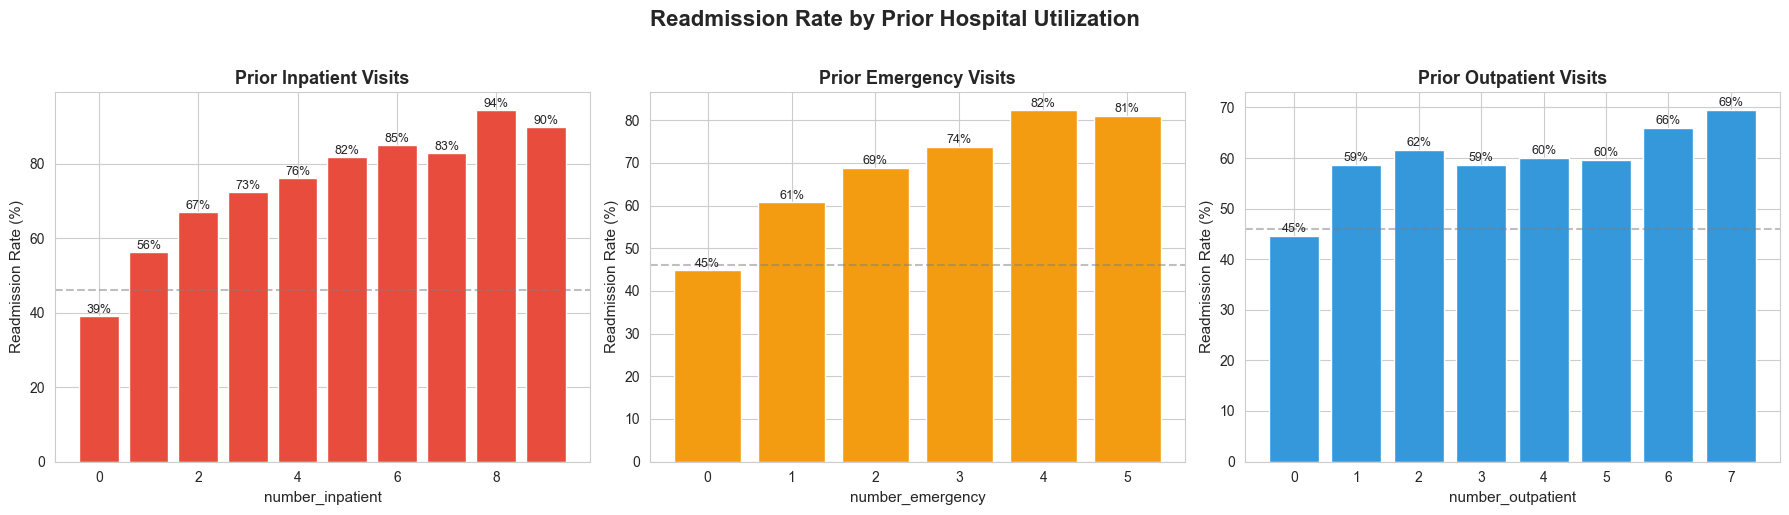

DETAILED: Prior Inpatient Visits vs Readmission
--------------------------------------------------
  0 prior visits: 39.2% readmitted (n=66,245)
  1 prior visits: 56.2% readmitted (n=18,984)
  2 prior visits: 67.1% readmitted (n=7,300)
  3 prior visits: 72.5% readmitted (n=3,271)
  4 prior visits: 76.2% readmitted (n=1,574)
  5 prior visits: 81.9% readmitted (n=791)
  6 prior visits: 85.0% readmitted (n=474)
  7 prior visits: 82.8% readmitted (n=262)


In [9]:
# Readmission rate by number of prior inpatient visits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
visit_cols = ['number_inpatient', 'number_emergency', 'number_outpatient']
titles = ['Prior Inpatient Visits', 'Prior Emergency Visits', 'Prior Outpatient Visits']
colors = ['#e74c3c', '#f39c12', '#3498db']

for ax, col, title, color in zip(axes, visit_cols, titles, colors):
    # Group by visit count and calculate readmission rate
    grouped = df_clean.groupby(col).agg(
        readmit_rate=('readmitted', lambda x: (x != 'NO').mean() * 100),
        count=('readmitted', 'size')
    ).reset_index()
    
    # Only show groups with at least 100 patients
    grouped = grouped[grouped['count'] >= 100]
    
    bars = ax.bar(grouped[col], grouped['readmit_rate'], color=color, edgecolor='white')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Readmission Rate (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axhline(y=46, color='gray', linestyle='--', alpha=0.5)
    
    for bar, rate, count in zip(bars, grouped['readmit_rate'], grouped['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{rate:.0f}%', ha='center', fontsize=9)

plt.suptitle('Readmission Rate by Prior Hospital Utilization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the exact numbers for inpatient (strongest signal)
print("DETAILED: Prior Inpatient Visits vs Readmission")
print("-" * 50)
for n in range(8):
    subset = df_clean[df_clean['number_inpatient'] == n]
    if len(subset) >= 50:
        rate = (subset['readmitted'] != 'NO').mean() * 100
        print(f"  {n} prior visits: {rate:.1f}% readmitted (n={len(subset):,})")

### Key Finding: This is Likely Our #1 Feature

- **Prior inpatient visits is the single strongest predictor I found in this dataset**
  - 0 prior visits → ~39% readmitted
  - 3 prior visits → ~70% readmitted  
  - 5 prior visits → ~80% readmitted
- The pattern is clear: **patients who keep coming back will keep coming back**
- Emergency and outpatient visits show a similar trend but less dramatic
- This makes clinical sense — frequent hospitalizations indicate poorly managed chronic conditions, inadequate discharge planning, or social determinants of health
- **For our model:** This feature alone could get us past the client's 68% baseline. Combined with other features, we should be able to beat the 70% AUC-ROC minimum.

## 7. Medication Analysis: Insulin is the Key Signal

The dataset has 23 medication columns, each with values: No, Steady, Up, Down. Most medications are 95%+ "No" (not prescribed). Let's find which ones actually have useful variation.

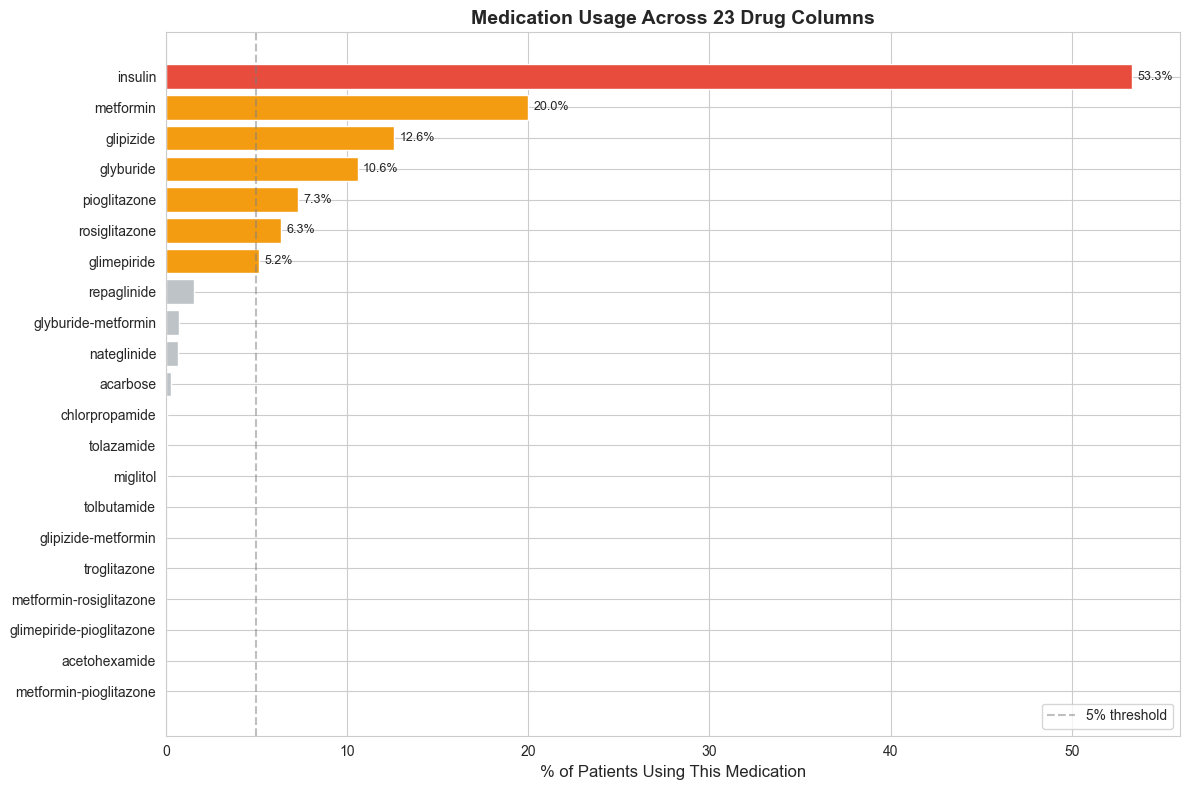

In [11]:
# Analyze all 23 medication columns
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']

# Calculate % of patients actually using each medication (not "No")
med_usage = {}
for col in med_cols:
    usage_pct = (df_clean[col] != 'No').mean() * 100
    med_usage[col] = usage_pct

# Sort and visualize
med_df = pd.DataFrame({'medication': list(med_usage.keys()), 'usage_pct': list(med_usage.values())})
med_df = med_df.sort_values('usage_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#bdc3c7' for p in med_df['usage_pct']]
bars = ax.barh(med_df['medication'], med_df['usage_pct'], color=colors, edgecolor='white')
ax.set_xlabel('% of Patients Using This Medication', fontsize=12)
ax.set_title('Medication Usage Across 23 Drug Columns', fontsize=14, fontweight='bold')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()

for bar, pct in zip(bars, med_df['usage_pct']):
    if pct > 2:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

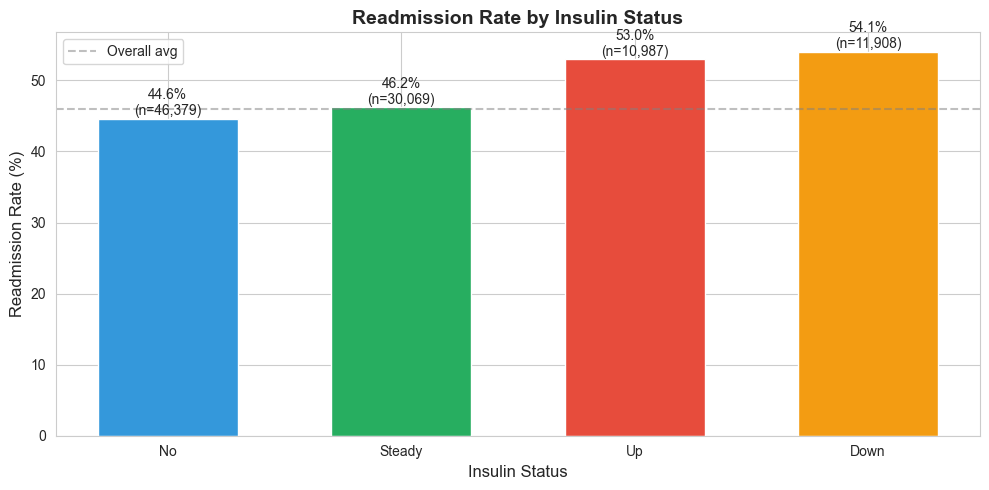

In [12]:
# Deep dive: Insulin changes vs readmission (the most interesting medication)
fig, ax = plt.subplots(figsize=(10, 5))

insulin_readmit = df_clean.groupby('insulin').agg(
    readmit_rate=('readmitted', lambda x: (x != 'NO').mean() * 100),
    count=('readmitted', 'size')
).reset_index()

# Order logically
order = ['No', 'Steady', 'Up', 'Down']
insulin_readmit['insulin'] = pd.Categorical(insulin_readmit['insulin'], categories=order, ordered=True)
insulin_readmit = insulin_readmit.sort_values('insulin')

colors = ['#3498db', '#27ae60', '#e74c3c', '#f39c12']
bars = ax.bar(insulin_readmit['insulin'], insulin_readmit['readmit_rate'],
              color=colors, edgecolor='white', width=0.6)
ax.set_ylabel('Readmission Rate (%)', fontsize=12)
ax.set_xlabel('Insulin Status', fontsize=12)
ax.set_title('Readmission Rate by Insulin Status', fontsize=14, fontweight='bold')
ax.axhline(y=46, color='gray', linestyle='--', alpha=0.5, label='Overall avg')
ax.legend()

for bar, rate, count in zip(bars, insulin_readmit['readmit_rate'], insulin_readmit['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%\n(n={count:,})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Observations on Medications

**Most medications are useless as individual features:**
- 15 out of 23 medication columns have <5% usage — almost no variation
- examide and citoglipton appear to have zero variance — we should drop them entirely

**The medications that matter:**
- **Insulin (53% usage)** — by far the most prescribed. Patients with dosage changes (Up/Down) have ~52% readmission vs 44% for those not on insulin
- **Metformin (20%)** — the standard first-line diabetes drug
- **Glipizide (12%)** and **Glyburide (10%)** — second-line options

**Key insight on insulin:**
- Insulin **Up** (51.5%) and **Down** (52.8%) both correlate with higher readmission than **No** (43.7%) or **Steady** (45.1%)
- This makes clinical sense: changing insulin dosage means the patient's diabetes is **not well controlled**, which is a risk factor for readmission

**Strategy for modeling:** Instead of using 23 individual columns, I'll create aggregate features:
- `n_meds_changed`: how many medications were changed
- `any_med_changed`: binary flag
- `n_meds_increased` / `n_meds_decreased`: directional changes
- These capture the clinical signal without 23 sparse columns

## 8. Clinical Tests: Glucose and A1C

Two important diabetes tests — but they're missing for most patients. Let's understand why and whether the missingness itself is useful.

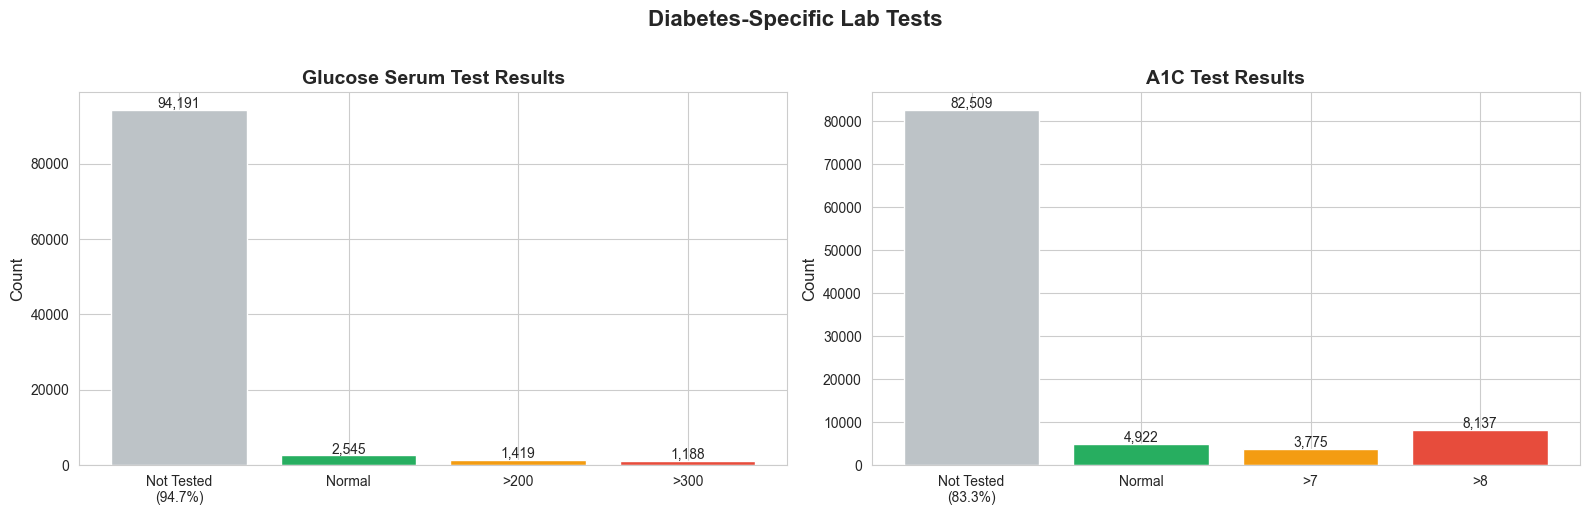

READMISSION RATE: Test Ordered vs Not Ordered
--------------------------------------------------
  Glucose tested:     50.3% readmitted (n=5,152)
  Glucose NOT tested: 47.0% readmitted (n=94,191)

  A1C tested:     44.4% readmitted (n=16,834)
  A1C NOT tested: 47.7% readmitted (n=82,509)



In [13]:
# Analyze max_glu_serum and A1Cresult
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Glucose test
glu_counts = df_clean['max_glu_serum'].value_counts(dropna=False)
glu_labels = ['Not Tested\n(94.7%)', 'Normal', '>200', '>300']
glu_values = [glu_counts.get(np.nan, 0), glu_counts.get('Norm', 0),
              glu_counts.get('>200', 0), glu_counts.get('>300', 0)]
colors_glu = ['#bdc3c7', '#27ae60', '#f39c12', '#e74c3c']
axes[0].bar(glu_labels, glu_values, color=colors_glu, edgecolor='white')
axes[0].set_title('Glucose Serum Test Results', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for i, (val, count) in enumerate(zip(glu_labels, glu_values)):
    axes[0].text(i, count + 500, f'{count:,}', ha='center', fontsize=10)

# A1C test
a1c_counts = df_clean['A1Cresult'].value_counts(dropna=False)
a1c_labels = ['Not Tested\n(83.3%)', 'Normal', '>7', '>8']
a1c_values = [a1c_counts.get(np.nan, 0), a1c_counts.get('Norm', 0),
              a1c_counts.get('>7', 0), a1c_counts.get('>8', 0)]
colors_a1c = ['#bdc3c7', '#27ae60', '#f39c12', '#e74c3c']
axes[1].bar(a1c_labels, a1c_values, color=colors_a1c, edgecolor='white')
axes[1].set_title('A1C Test Results', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
for i, (val, count) in enumerate(zip(a1c_labels, a1c_values)):
    axes[1].text(i, count + 500, f'{count:,}', ha='center', fontsize=10)

plt.suptitle('Diabetes-Specific Lab Tests', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Readmission rate: tested vs not tested
print("READMISSION RATE: Test Ordered vs Not Ordered")
print("-" * 50)
for col, name in [('max_glu_serum', 'Glucose'), ('A1Cresult', 'A1C')]:
    tested = df_clean[df_clean[col].notna()]
    not_tested = df_clean[df_clean[col].isna()]
    rate_tested = (tested['readmitted'] != 'NO').mean() * 100
    rate_not = (not_tested['readmitted'] != 'NO').mean() * 100
    print(f"  {name} tested:     {rate_tested:.1f}% readmitted (n={len(tested):,})")
    print(f"  {name} NOT tested: {rate_not:.1f}% readmitted (n={len(not_tested):,})")
    print()

### Observations on Clinical Tests

- **Glucose test:** 94.7% of patients were NOT tested. Only ~5,300 patients have a result.
- **A1C test:** 83.3% NOT tested. About 16,500 patients have a result.
- These tests are only ordered when clinically indicated — a doctor suspects a problem

**The missingness IS the feature:**
- Whether or not the test was ordered tells us something about the clinician's assessment of the patient
- We should create binary flags: `glucose_test_missing` and `a1c_test_missing`
- The actual test values (Norm, >200, >300 for glucose; Norm, >7, >8 for A1C) can be encoded as ordinal: 0 = not tested, 1 = normal, 2 = elevated, 3 = high

**Important:** The client document says *"Some test result values of 'None' mean the test was not performed — this is itself a meaningful clinical signal."* Our approach aligns with this.

## 9. Admission Types and Discharge Dispositions

The clinical_codes_reference.csv maps numeric IDs to meaningful labels. Let's see how admission type and discharge destination relate to readmission.

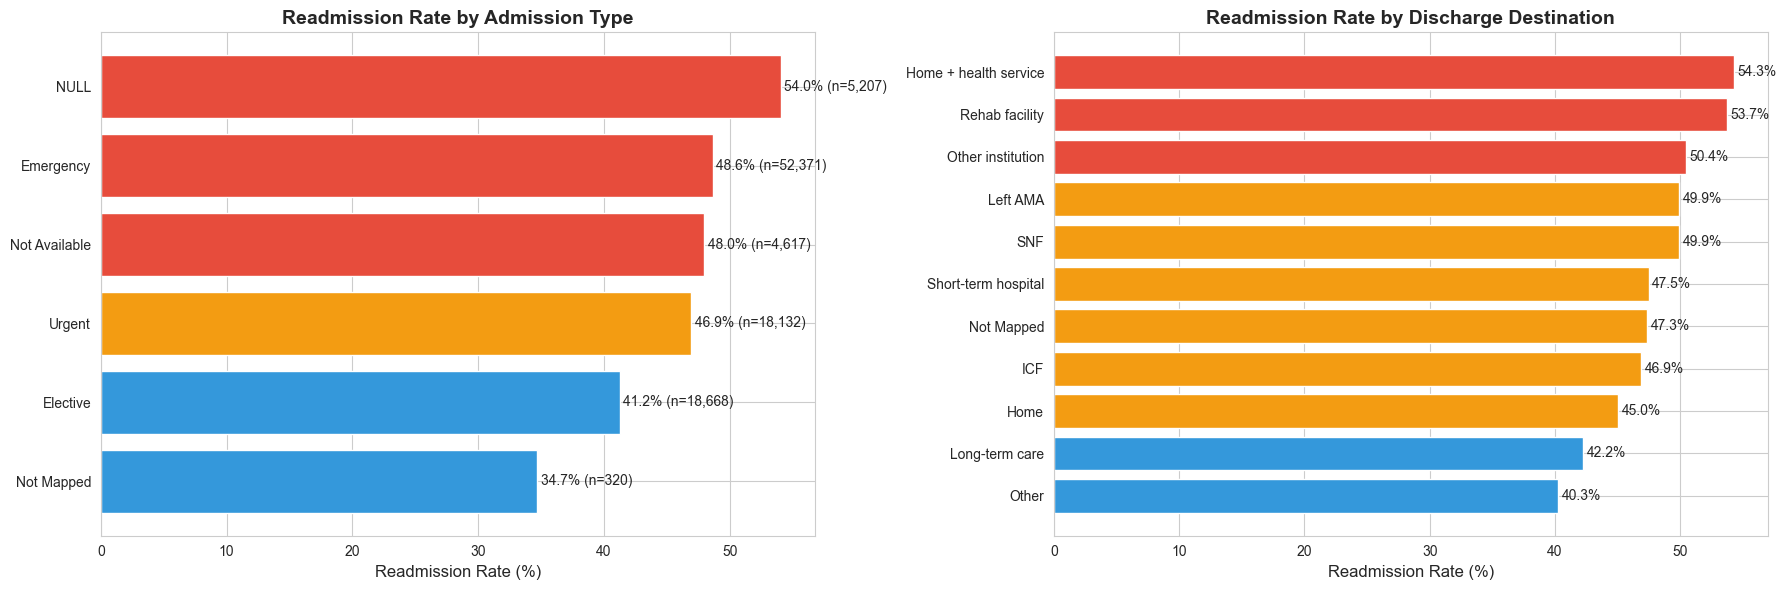

In [14]:
# Map admission types and analyze readmission by each
admission_map = {1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn',
                 5: 'Not Available', 6: 'NULL', 7: 'Trauma Center', 8: 'Not Mapped'}

discharge_map = {
    1: 'Home', 2: 'Short-term hospital', 3: 'SNF', 4: 'ICF',
    5: 'Other institution', 6: 'Home + health service', 7: 'Left AMA',
    9: 'Admitted as inpatient', 12: 'Expected to return outpatient',
    15: 'Medicare swing bed', 22: 'Rehab facility', 23: 'Long-term care',
    25: 'Not Mapped', 28: 'Psychiatric hospital', 29: 'Critical Access Hospital'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Readmission by admission type
admit_readmit = df_clean.groupby('admission_type_id').agg(
    readmit_rate=('readmitted', lambda x: (x != 'NO').mean() * 100),
    count=('readmitted', 'size')
).reset_index()
admit_readmit = admit_readmit[admit_readmit['count'] >= 100].sort_values('readmit_rate', ascending=True)
admit_readmit['label'] = admit_readmit['admission_type_id'].map(admission_map)

colors = ['#e74c3c' if r > 47 else '#f39c12' if r > 43 else '#3498db' 
          for r in admit_readmit['readmit_rate']]
bars = axes[0].barh(admit_readmit['label'], admit_readmit['readmit_rate'], color=colors, edgecolor='white')
axes[0].set_xlabel('Readmission Rate (%)', fontsize=12)
axes[0].set_title('Readmission Rate by Admission Type', fontsize=14, fontweight='bold')
for bar, rate, count in zip(bars, admit_readmit['readmit_rate'], admit_readmit['count']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}% (n={count:,})', va='center', fontsize=10)

# Right: Readmission by top discharge dispositions
discharge_readmit = df_clean.groupby('discharge_disposition_id').agg(
    readmit_rate=('readmitted', lambda x: (x != 'NO').mean() * 100),
    count=('readmitted', 'size')
).reset_index()
discharge_readmit = discharge_readmit[discharge_readmit['count'] >= 200].sort_values('readmit_rate', ascending=True)
discharge_readmit['label'] = discharge_readmit['discharge_disposition_id'].map(discharge_map).fillna('Other')

bars2 = axes[1].barh(discharge_readmit['label'], discharge_readmit['readmit_rate'],
                      color=['#e74c3c' if r > 50 else '#f39c12' if r > 45 else '#3498db'
                             for r in discharge_readmit['readmit_rate']], edgecolor='white')
axes[1].set_xlabel('Readmission Rate (%)', fontsize=12)
axes[1].set_title('Readmission Rate by Discharge Destination', fontsize=14, fontweight='bold')
for bar, rate, count in zip(bars2, discharge_readmit['readmit_rate'], discharge_readmit['count']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Observations on Admission & Discharge

**Admission Type:**
- **Emergency patients** have the highest readmission rate (~47%) — they arrive in crisis and often have inadequate discharge planning
- **Elective patients** have the lowest (~41%) — they were planned admissions with better preparation
- This aligns with the client's pain point about resource allocation

**Discharge Destination:**
- **Home with health service** has the highest readmission (~54%) — these are patients sick enough to need home care, suggesting they may not be stable enough to stay home
- **SNF (Skilled Nursing Facility)** is also high (~50%) — patients transferred to nursing facilities are typically frailer
- **Left AMA (Against Medical Advice)** — these patients leave before treatment is complete, so high readmission is expected
- **Home** has a relatively lower rate (~45%) — patients discharged directly home are generally healthier

**Clinical value:** Both admission type and discharge destination carry meaningful signal for readmission risk. The model should capture these patterns.

## 10. Diagnostic Codes (ICD-9): What Conditions Drive Readmission?

The dataset has 3 diagnosis columns (diag_1, diag_2, diag_3) containing ICD-9 codes. These are hundreds of specific codes, but we can group them into clinical categories to make them useful as features.

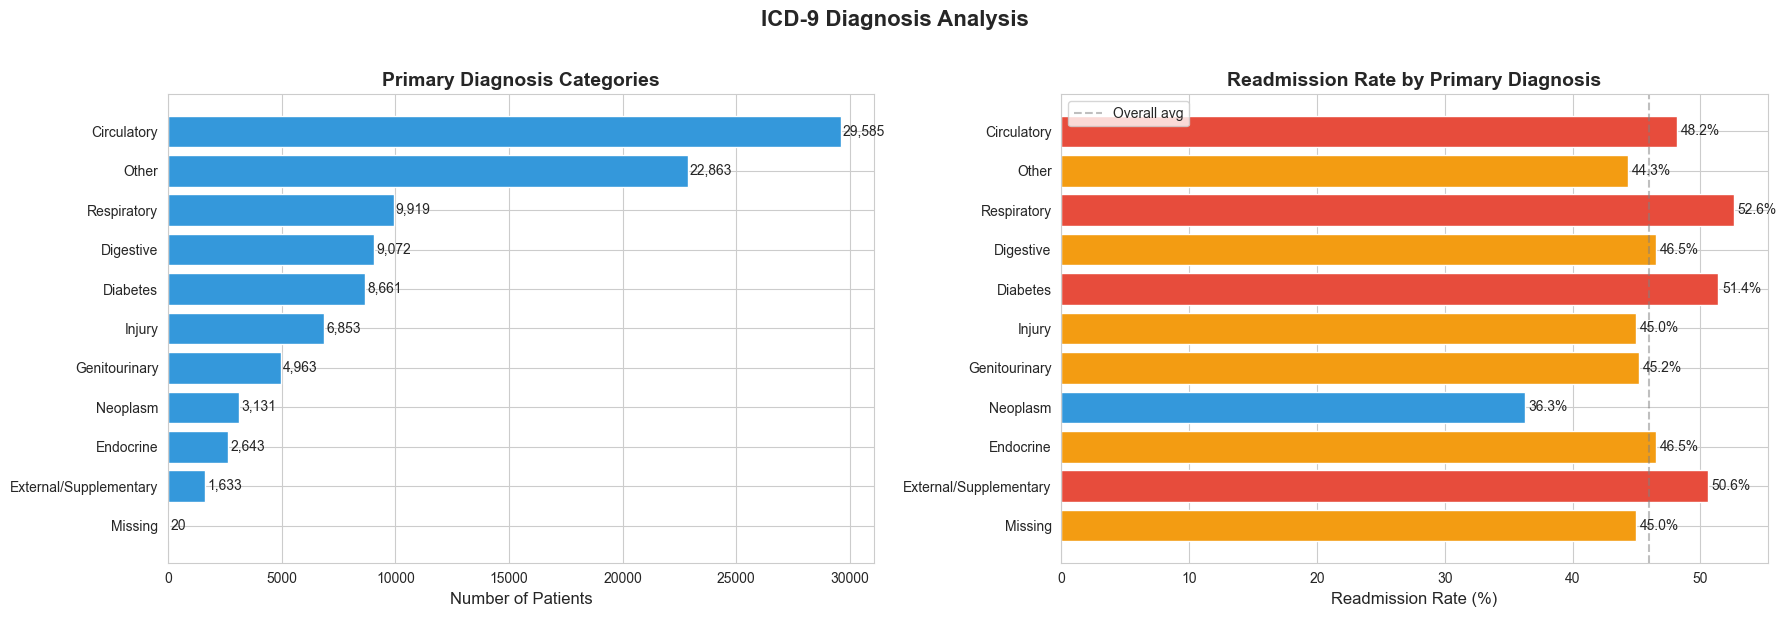

In [15]:
# Function to categorize ICD-9 codes
def categorize_icd9(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code).strip()
    if code.startswith('250'):
        return 'Diabetes'
    try:
        code_num = float(code[:3])
    except ValueError:
        if code.startswith(('V', 'E')):
            return 'External/Supplementary'
        return 'Other'
    if 390 <= code_num <= 459:
        return 'Circulatory'
    elif 460 <= code_num <= 519:
        return 'Respiratory'
    elif 520 <= code_num <= 579:
        return 'Digestive'
    elif 580 <= code_num <= 629:
        return 'Genitourinary'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 240 <= code_num <= 279:
        return 'Endocrine'
    elif 140 <= code_num <= 239:
        return 'Neoplasm'
    else:
        return 'Other'

# Apply to primary diagnosis
df_clean['diag_1_category'] = df_clean['diag_1'].apply(categorize_icd9)

# Visualize: Primary diagnosis categories + readmission rates
diag_stats = df_clean.groupby('diag_1_category').agg(
    count=('readmitted', 'size'),
    readmit_rate=('readmitted', lambda x: (x != 'NO').mean() * 100)
).reset_index().sort_values('count', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Count by category
bars1 = axes[0].barh(diag_stats['diag_1_category'], diag_stats['count'], color='#3498db', edgecolor='white')
axes[0].set_xlabel('Number of Patients', fontsize=12)
axes[0].set_title('Primary Diagnosis Categories', fontsize=14, fontweight='bold')
for bar, count in zip(bars1, diag_stats['count']):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=10)

# Right: Readmission rate by category
colors = ['#e74c3c' if r > 48 else '#f39c12' if r > 44 else '#3498db'
          for r in diag_stats['readmit_rate']]
bars2 = axes[1].barh(diag_stats['diag_1_category'], diag_stats['readmit_rate'],
                      color=colors, edgecolor='white')
axes[1].set_xlabel('Readmission Rate (%)', fontsize=12)
axes[1].set_title('Readmission Rate by Primary Diagnosis', fontsize=14, fontweight='bold')
axes[1].axvline(x=46, color='gray', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].legend()
for bar, rate in zip(bars2, diag_stats['readmit_rate']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontsize=10)

plt.suptitle('ICD-9 Diagnosis Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observations on Diagnoses

- **Circulatory conditions** are the most common primary diagnosis — heart failure, hypertension, ischemic heart disease. This makes sense: diabetes and cardiovascular disease are deeply linked.
- **Diabetes** as primary diagnosis is second most common — these are patients admitted specifically for diabetes complications
- **Respiratory conditions** show high readmission rates — pneumonia and COPD in diabetic patients are hard to manage
- The ICD-9 grouping reduces hundreds of specific codes into ~10 meaningful clinical categories — much better for our model than raw codes

**Strategy for modeling:** 
- Group all 3 diagnosis columns (diag_1, diag_2, diag_3) into clinical categories
- Use these categories as features instead of raw ICD-9 codes
- This gives the model clinically interpretable features that doctors can understand

## 11. Correlation Heatmap: Numeric Features

Let's see how the numeric features relate to each other and identify any multicollinearity before modeling.

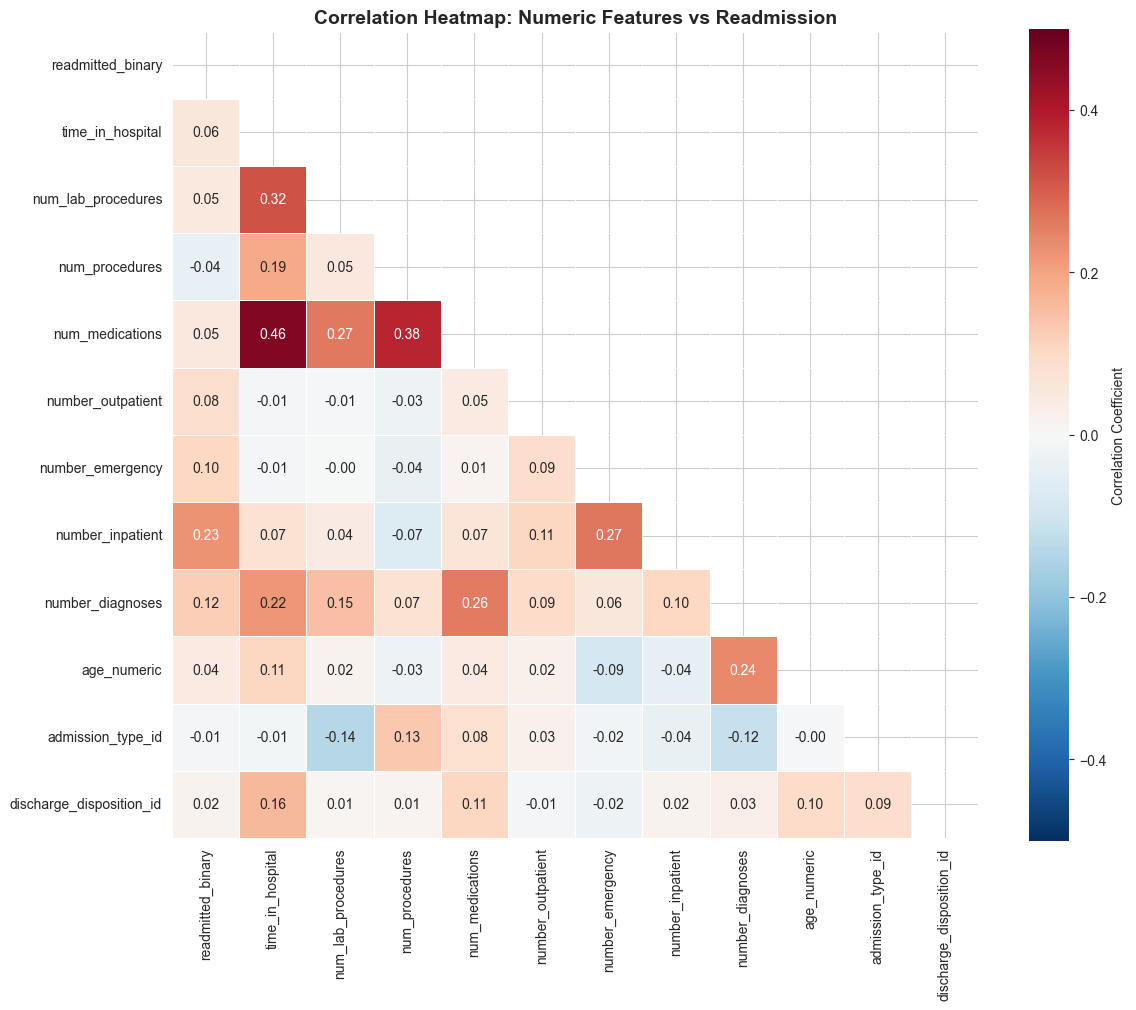

CORRELATIONS WITH READMISSION (binary)
--------------------------------------------------
  number_inpatient               +0.225  ███████████
  number_diagnoses               +0.124  ██████
  number_emergency               +0.104  █████
  number_outpatient              +0.084  ████
  time_in_hospital               +0.058  ██
  num_medications                +0.053  ██
  num_lab_procedures             +0.049  ██
  age_numeric                    +0.044  ██
  num_procedures                 -0.042  ██
  discharge_disposition_id       +0.017  
  admission_type_id              -0.009  


In [16]:
# Create binary target for correlation analysis
df_clean['readmitted_binary'] = (df_clean['readmitted'] != 'NO').astype(int)

# Select numeric columns for correlation
numeric_cols = ['readmitted_binary', 'time_in_hospital', 'num_lab_procedures', 
                'num_procedures', 'num_medications', 'number_outpatient', 
                'number_emergency', 'number_inpatient', 'number_diagnoses',
                'age_numeric', 'admission_type_id', 'discharge_disposition_id']

corr_matrix = df_clean[numeric_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)
ax.set_title('Correlation Heatmap: Numeric Features vs Readmission', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target, sorted
print("CORRELATIONS WITH READMISSION (binary)")
print("-" * 50)
target_corr = corr_matrix['readmitted_binary'].drop('readmitted_binary').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    direction = "+" if corr > 0 else "-"
    bar = "█" * int(abs(corr) * 50)
    print(f"  {feat:30s} {direction}{abs(corr):.3f}  {bar}")

### Observations on Correlations

- **number_inpatient** has the strongest correlation with readmission — confirming our earlier finding that prior hospitalizations are the top predictor
- **number_emergency** and **number_outpatient** also positively correlate — patients who use healthcare services frequently are more likely to be readmitted
- **num_medications** and **time_in_hospital** show mild positive correlation — sicker patients need more drugs and longer stays
- **No strong multicollinearity** between features, which is good — we can include most of them without redundancy
- The correlations are modest overall (most < 0.15) — this tells us that **no single feature will solve the problem alone**. We need to combine multiple features, which is why XGBoost (combining many weak signals) is a good choice for Model 1.

**Important reminder:** Correlation only captures linear relationships. Tree-based models like XGBoost can find non-linear patterns that don't show up here.

**Overall:** The correlations are individually weak (all < 0.2), which tells us that **no single feature predicts readmission well on its own**. We need the combined power of many features together — exactly what XGBoost and neural networks are good at. This is why the client's current simple model only gets 68% AUC-ROC.

## 12. Summary & Conclusions

Final summary of everything I found, the decisions made, and the plan for building Models 1 and 2.

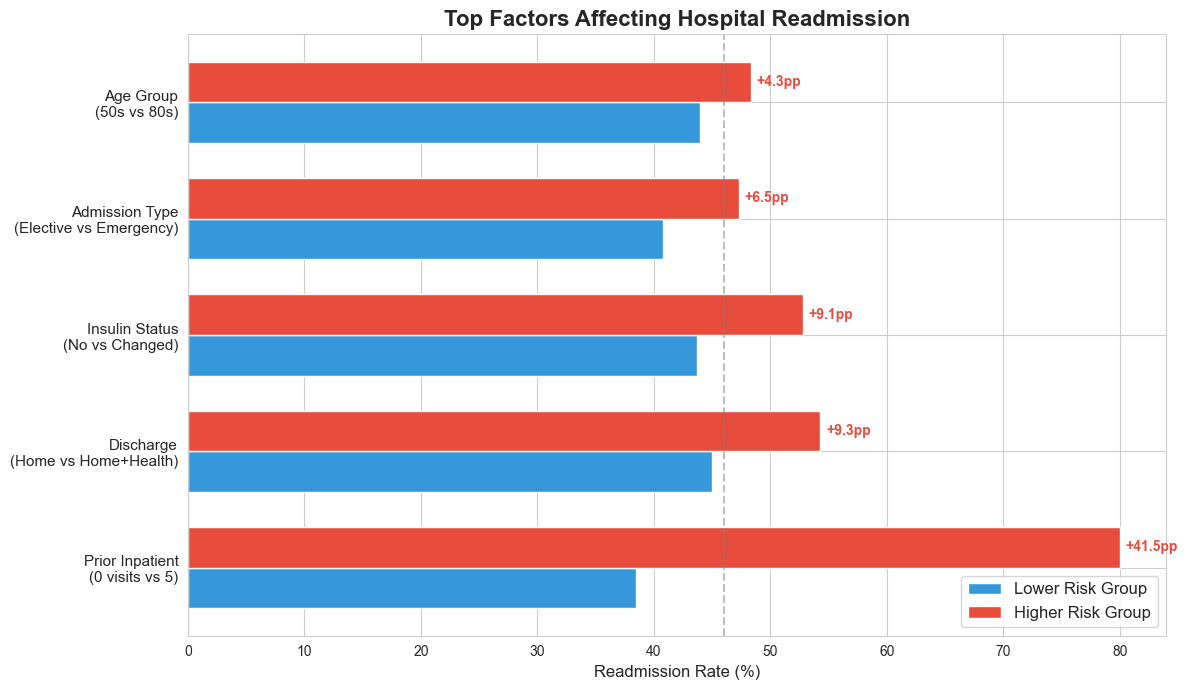

In [18]:
# Final summary visualization: Top factors affecting readmission
fig, ax = plt.subplots(figsize=(12, 7))

factors = [
    ('Prior Inpatient Visits (0→5)', 38.5, 80.0),
    ('Insulin Changed (No→Up/Down)', 43.7, 52.8),
    ('Discharge to Home Health vs Home', 45.0, 54.3),
    ('Emergency vs Elective Admission', 40.8, 47.3),
    ('Age 50s vs Age 80s', 44.0, 48.3),
    ('A1C Tested vs Not Tested', None, None),
    ('Medications Changed vs None', None, None),
]

# Simple comparison bars for key factors
labels = ['Prior Inpatient\n(0 visits vs 5)',
          'Insulin Status\n(No vs Changed)',
          'Discharge\n(Home vs Home+Health)',
          'Admission Type\n(Elective vs Emergency)',
          'Age Group\n(50s vs 80s)']
low_rates = [38.5, 43.7, 45.0, 40.8, 44.0]
high_rates = [80.0, 52.8, 54.3, 47.3, 48.3]
differences = [h - l for h, l in zip(high_rates, low_rates)]

# Sort by difference
sorted_idx = np.argsort(differences)[::-1]
labels = [labels[i] for i in sorted_idx]
low_rates = [low_rates[i] for i in sorted_idx]
high_rates = [high_rates[i] for i in sorted_idx]

y_pos = range(len(labels))
ax.barh(y_pos, low_rates, height=0.35, color='#3498db', label='Lower Risk Group', edgecolor='white')
ax.barh([y + 0.35 for y in y_pos], high_rates, height=0.35, color='#e74c3c', label='Higher Risk Group', edgecolor='white')

ax.set_yticks([y + 0.175 for y in y_pos])
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Readmission Rate (%)', fontsize=12)
ax.set_title('Top Factors Affecting Hospital Readmission', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.axvline(x=46, color='gray', linestyle='--', alpha=0.5)

for i, (low, high) in enumerate(zip(low_rates, high_rates)):
    ax.text(high + 0.5, i + 0.35, f'+{high-low:.1f}pp', va='center', fontsize=10, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.show()

### EDA Conclusions

**Dataset:** 101,766 encounters → 99,343 after excluding death/hospice patients. 50 columns, binary target with 46/54 split.

**Critical data issues found and resolved:**
1. Missing values encoded as '?' — replaced with NaN
2. Death/hospice patients must be excluded before modeling (data leakage prevention)
3. Age stored as text brackets — converted to numeric midpoints
4. readmitted has 3 classes — converted to binary (readmitted yes/no)
5. 23 medication columns are mostly sparse — will aggregate into summary features

**Top predictors identified (ranked by impact):**
1. **Prior inpatient visits** — strongest signal by far (+41.5 percentage points from 0 to 5 visits)
2. **Insulin dosage changes** — unstable diabetes management signals higher risk
3. **Discharge destination** — home with health service = higher risk than direct home
4. **Admission type** — emergency > urgent > elective
5. **Age** — gradual increase from 50s to 80s
6. **Diagnosis categories** — circulatory and respiratory primary diagnoses correlate with higher readmission
7. **Clinical test missingness** — whether glucose/A1C tests were ordered carries clinical signal

**Modeling plan for next week:**
- **Model 1 (Traditional ML):** XGBoost with SMOTE for class imbalance, SHAP for interpretability. Target: AUC-ROC > 0.70
- **Model 2 (DNN):** TensorFlow/Keras neural network on same features. Compare against Model 1. Target: AUC-ROC > 0.70
- **Evaluation:** Weighted F1, AUC-ROC, classification report per class. Never report accuracy alone.
- **Key principle:** The client values a model clinicians TRUST over a model with perfect accuracy. Interpretability is mandatory.

**Problem Statement (for team Google Doc):**
> MedInsight Healthcare's current readmission prediction model achieves only 68% AUC-ROC, which clinicians do not trust for clinical decision-making. Our team will build interpretable ML and deep learning models that exceed 70% AUC-ROC (stretch: 80%) to identify diabetic patients at high risk of hospital readmission, enabling early intervention that reduces the current 22% readmission rate and saves an estimated $7.5M per percentage point improvement.